In [105]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# append my path
project_root = os.path.abspath('..')
sys.path.append(project_root)

from utils.utils import *

%pip install oasis-deconv
from oasis.functions import deconvolve

Note: you may need to restart the kernel to use updated packages.


In [106]:
data = load_data()
print_info(data)

matched cells: 47
templates: ['locally_sparse_noise', 'natural_scenes']

session A (three_session_A)
  t: (115471,), dff: (47, 115471), roi_masks: (47, 512, 512)
  stim 'drifting_gratings': (628, 5) cols=['temporal_frequency', 'orientation', 'blank_sweep', 'start', 'end']

session B (three_session_B)
  t: (113850,), dff: (47, 113850), roi_masks: (47, 512, 512)
  stim 'natural_scenes': (5950, 3) cols=['frame', 'start', 'end']
  stim 'static_gratings': (6000, 5) cols=['orientation', 'spatial_frequency', 'phase', 'start', 'end']

session C (three_session_C)
  t: (105738,), dff: (47, 105738), roi_masks: (47, 512, 512)
  stim 'locally_sparse_noise': (8880, 3) cols=['frame', 'start', 'end']


# Neural Data preprocessing

In [107]:
### Spike transformation function definition
def infer_spikes_oasis(session, fs):
    dff = session["dff"]
    n_cells, n_time = dff.shape
    spikes = np.zeros_like(dff)
    calcium = np.zeros_like(dff)
    for i in range(n_cells):
        c, s, b, g, lam = deconvolve(dff[i], penalty = 1) # tau_d=0.1, framerate=fs)
        spikes[i] = s
        calcium[i] = c
    return spikes, calcium

### Data processing
for name, session in data["sessions"].items():
    fs = 1.0 / np.median(np.diff(session["t"]))
    spikes, calcium = infer_spikes_oasis(session, fs)
    session["spikes"] = spikes
    session["calcium_fit"] = calcium

In [108]:
save_data(data, "data_with_spikes")

In [109]:
data = load_saved_data("data_with_spikes")

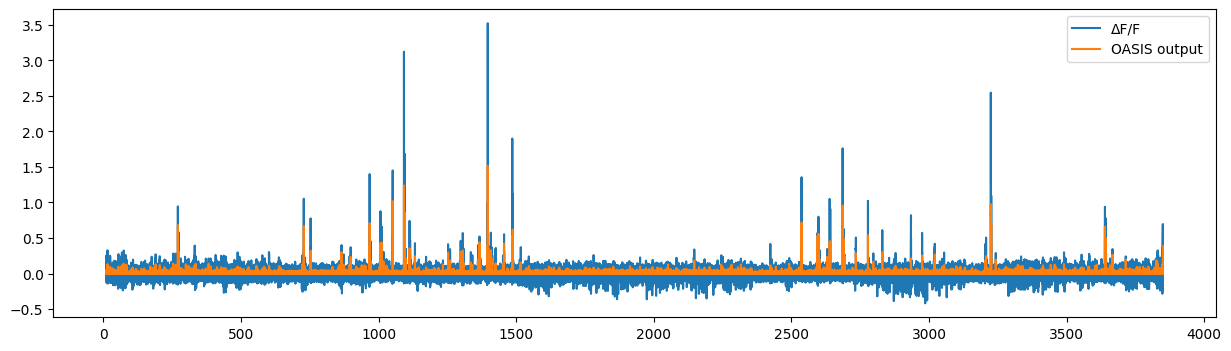

In [110]:
plt.figure(figsize=(15, 4))

plt.plot(session["t"], session["dff"][0], label="ΔF/F")
plt.plot(session["t"], session["spikes"][0], label="OASIS output")

plt.legend()

# Running Speed preprocessing

In [111]:
def preprocess_running_speed(
    data: dict,
    high: float = 3.0,
    order: int = 3,
    clip_speed: bool = True,
    running_threshold: float = 2.0,
    ) -> dict:

    for name, session in data["sessions"].items():
        speed = np.asarray(session["running_speed"][0], dtype=float)
        t = np.asarray(session["running_speed"][1], dtype=float)
        dt = np.median(np.diff(t))

        fs = 1.0 / dt
        nyquist = 0.5 * fs
        if not (0 < high < nyquist):
            raise ValueError(f"{name}: high must be between 0 and {nyquist:.3f} Hz, got {high}")

        valid = np.isfinite(speed)

        # We have nans at beginning and end of the speed trace,
        # so we need to interpolate to fill them in before filtering.
        speed_interp = np.interp(
            np.arange(speed.size),
            np.flatnonzero(valid),
            speed[valid],
        )

        b, a = signal.butter(order, high, btype="low", fs=fs)
        speed_filtered = signal.filtfilt(b, a, speed_interp)

        # clip running speed at 0
        if clip_speed:
            speed_filtered = np.clip(speed_filtered, 0, None)

        # Separate filtered speed into two kinematic phases: still (0) vs running (1).
        phases = np.full(speed_filtered.shape, -1, dtype=int)
        phases[speed_filtered <= running_threshold] = 0
        phases[speed_filtered > running_threshold] = 1

        # Restore missing values in filtered signal while keeping phase=-1 for invalid points.
        speed_filtered[~valid] = np.nan
        phases[~valid] = -1
        session["running_speed_filtered"] = np.vstack([speed_filtered, t])
        session["running_speed_phase"] = phases

    return data

In [112]:
data = preprocess_running_speed(data, high=5, order=3, clip_speed=True, running_threshold=5.0)

In [113]:
def plot_running_speed(data, session="B", t=(0, 100)):
    """Plot raw and filtered running speed with phase background blocks."""
    session_data = data["sessions"][session]

    speed_raw, time_raw = (np.asarray(a, dtype=float) for a in session_data["running_speed"])
    speed_filt, time_filt = (np.asarray(a, dtype=float) for a in session_data["running_speed_filtered"])

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axs[0].plot(time_raw, speed_raw, color="0.2", lw=0.8)
    axs[0].set(xlim=t, title="Original Running Speed", ylabel="Speed (cm/s)")

    axs[1].plot(time_filt, speed_filt, color="0.2", lw=0.8)
    axs[1].set(xlim=t, title="Filtered Running Speed", ylabel="Speed (cm/s)", xlabel="Time (s)")

    # Shade contiguous phase blocks on both subplots.

    phase = np.asarray(session_data["running_speed_phase"], dtype=int)
    
    phase_names = {-1: "Invalid", 0: "Still", 1: "Running"}
    phase_colors = {-1: "0.8", 0: "tab:blue", 1: "tab:red"}

    change_points = np.flatnonzero(np.diff(phase)) + 1 # get the indices where the phase changes
    block_starts = np.concatenate(([0], change_points))
    block_ends = np.concatenate((change_points, [phase.size]))

    seen_labels = set()
    for start, end in zip(block_starts, block_ends):
        p = phase[start]
        label = phase_names.get(p, f"Phase {p}") if p not in seen_labels else None
        seen_labels.add(p)
        for ax in axs:
            ax.axvspan(
                time_filt[start], time_filt[end - 1],
                color=phase_colors.get(p, "0.5"), alpha=0.2, label=label,
            )

    axs[1].legend(loc="upper right")
    fig.tight_layout()
    return fig, axs

In [114]:
# safe data 
save_data(data, "data_with_spikes_and_speed")

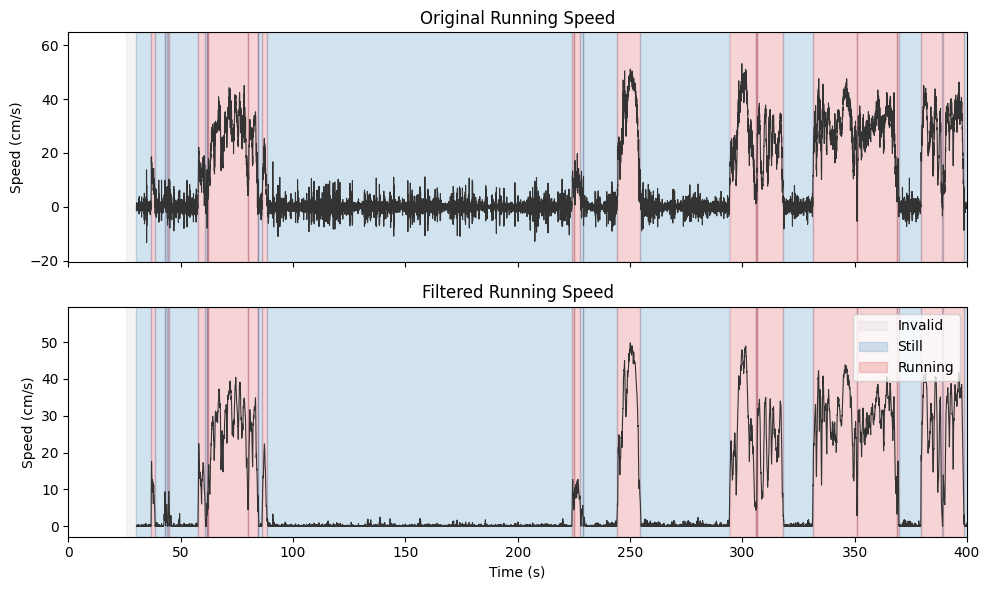

In [115]:
fig, axs = plot_running_speed(data, session="B", t=(0, 400))
plt.show()

# Extract the running speed across different stimulus
Not in the poster

Under this section, to see if there is difference of running speed between different stimulus, I seperated the stimulus into four different kinds:
drifting_gratings, static_gratings, natural_scenes, locally_sparse_noise
and further extract the running speed within the stimulus onset across different stimulus 

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

STIMULUS_SESSION_MAP = {
    "drifting_gratings":    "A",
    "static_gratings":      "B",
    "natural_scenes":       "B",
    "locally_sparse_noise": "C",
}

def get_running_speed_by_stimulus(data, stimulus_session_map=STIMULUS_SESSION_MAP, filtered=True):
    """
    Extract running speed values during each stimulus's presentation trials.
    Uses the filtered (smoothed, clipped) speed trace by default.
    """
    stimulus_speed = {}

    for stim_name, session in stimulus_session_map.items():
        s = data["sessions"][session]
        key = "running_speed_filtered" if filtered else "running_speed"
        speed = s[key][0]
        stim_table = s["stim_tables"][stim_name]

        starts = stim_table["start"].astype(int).values
        ends = stim_table["end"].astype(int).values

        speed_values = [speed[start:end + 1] for start, end in zip(starts, ends)]
        stimulus_speed[stim_name] = np.concatenate(speed_values) if speed_values else np.array([])

    return stimulus_speed


def plot_speed_by_stimulus(stimulus_speed, ax=None):
    """
    Plot running speed distributions across the four stimulus types as boxplots,
    with mean values shown as markers and text labels.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    rows = []
    for stim_name, speeds in stimulus_speed.items():
        for v in speeds:
            rows.append({"stimulus": stim_name, "speed": v})
    df_long = pd.DataFrame(rows)

    sns.boxplot(data=df_long, x="stimulus", y="speed", ax=ax,
                showfliers=False, width=0.5, palette="Set2",
                showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white",
                           "markeredgecolor": "black", "markersize": 7})

    # Annotate each box with its mean value as text
    stim_order = list(stimulus_speed.keys())
    for i, stim_name in enumerate(stim_order):
        mean_val = np.mean(stimulus_speed[stim_name])
        ax.text(i, mean_val, f"{mean_val:.2f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color="black")

    ax.set_xlabel("stimulus")
    ax.set_ylabel("running speed (cm/s)")
    ax.set_title("Running speed across stimulus types")
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

    return ax

## Compare the running speed across different stimulus
Here is the plotting session for running speed across the four stimulus

/var/folders/42/yzjg5hd11vv65hsck7wh0lb00000gn/T/ipykernel_16339/3318748824.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="stimulus", y="speed", ax=ax,


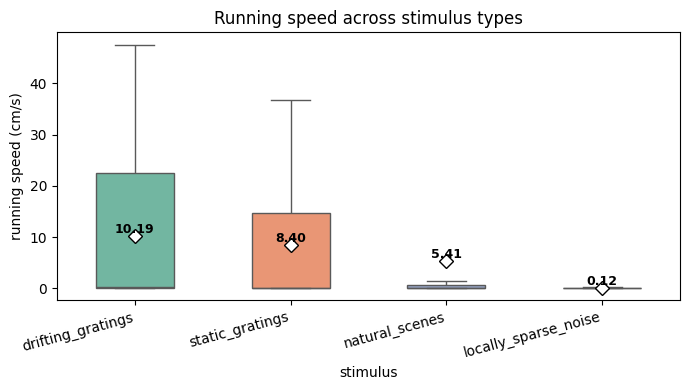

In [117]:

data = preprocess_running_speed(data)

stimulus_speed = get_running_speed_by_stimulus(data, filtered=True)

fig, ax = plt.subplots(figsize=(7, 4))
plot_speed_by_stimulus(stimulus_speed, ax=ax)
plt.tight_layout()
plt.show()

# Visualize natural scence and further comparison

Not in the poster

This section aims to see if mice would respond differently (movement and neural activity) with "aversive" and "neutral" natural scenes. (No rewarding scene since there is no obvious reward for mice)

### Summary: Not really see the difference both in neural activity and running speed between aversive or neutral scenes


In [118]:
# Check how many natural scenes are there in this dataset
len(data["templates"]["natural_scenes"])


118

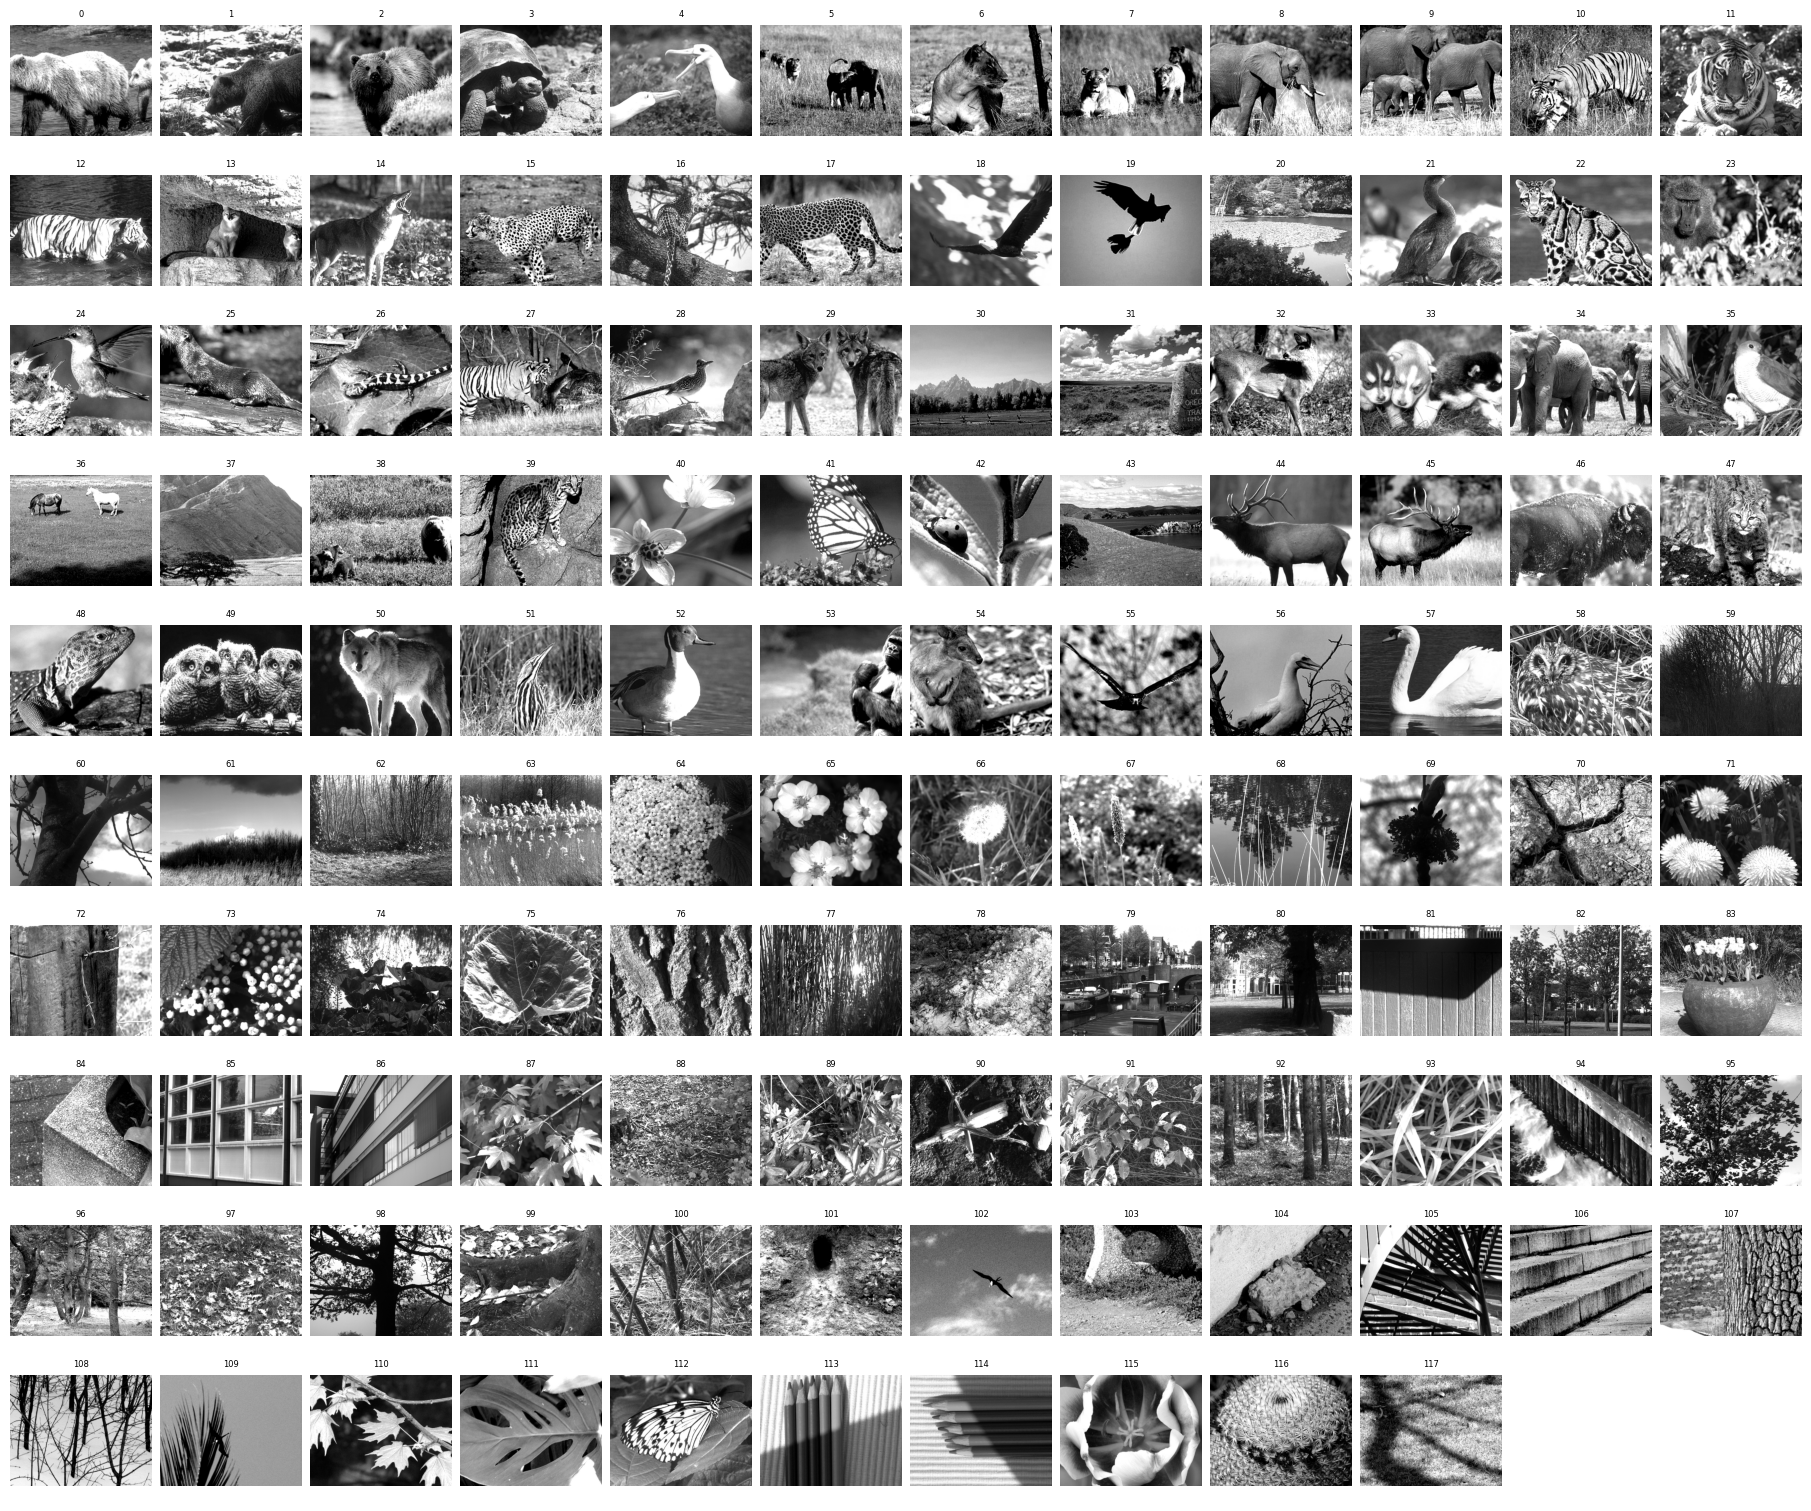

In [119]:
# Show all the scenes
def show_all_natural_scenes(data, ncols=12):
    '''this function could show all the natural stimulation
    118 in total'''
    tmpl = data["templates"]["natural_scenes"]
    n = tmpl.shape[0]                          # Total 118 frame
    nrows = int(np.ceil(n / ncols))           

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 1.5, nrows * 1.5),   
        constrained_layout=True,
    )
    axes = axes.flat                           

    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(tmpl[i], cmap="gray")
            ax.set_title(str(i), fontsize=6)   
        ax.axis("off")                         
    # return fig

##### 
show_all_natural_scenes(data)


In [ ]:
# Categorized the pictures into aversive and neutral 
aversive_frames = [
    0, 1, 2,      # bears
    4,            # Bird
    6, 7,         # lions
    8, 9,         # elephant       
    10, 11, 12,   # tigers close-up
    13, 14,       # coyote howling
    15, 16,       # cheetah
    17,           # leopard
    18,           # eagle
    19,           # birds fighting
    21,           # bird
    22,           # leopard/jaguar close-up
    23,           # monkey
    25,           # Otter
    27,           # tiger
    28,           # bird
    29,           # coyotes
    34,           # elephants
    35,           # bird
    39,           # leopard camouflaged
    47,           # bobcat
    49,           # bird
    50,           # wolf/coyote
    51,52,        # bird
    55,56,        # hawk flying
    58,           # owl
    102,          # bird
]

frame_to_category = {i: "aversive" for i in aversive_frames}
for i in range(118):
    if i not in frame_to_category:
        frame_to_category[i] = "neutral"

In [20]:
def get_speed_per_trial(data, session, stim_name, frame_to_category, filtered=True):
    """
    For each stimulus presentation trial, extract the mean running speed
    during that trial, and tag it with its frame number and category.

    Returns
    -------
    pd.DataFrame with columns: frame, category, mean_speed, start, end
    """
    s = data["sessions"][session]
    key = "running_speed_filtered" if filtered else "running_speed"
    speed = s[key][0]
    stim_table = s["stim_tables"][stim_name].copy()

    # Exclude blank sweeps (frame == -1, no image shown)
    stim_table = stim_table[stim_table["frame"] != -1].reset_index(drop=True)

    mean_speeds = []
    for _, row in stim_table.iterrows():
        start, end = int(row["start"]), int(row["end"])
        trial_speed = speed[start:end + 1]
        mean_speeds.append(np.nanmean(trial_speed))

    stim_table["mean_speed"] = mean_speeds
    stim_table["category"] = stim_table["frame"].map(frame_to_category)

    return stim_table

In [ ]:
trial_df = get_speed_per_trial(data, session="B", stim_name="natural_scenes",
                                 frame_to_category=frame_to_category)

print(trial_df.head())

   frame  start    end  mean_speed  category
0     35  16096  16103    0.133995  aversive
1     49  16104  16111    0.103649  aversive
2    107  16111  16118    0.052961   neutral
3     53  16119  16126    0.018418   neutral
4    110  16126  16133    0.000000   neutral


/var/folders/42/yzjg5hd11vv65hsck7wh0lb00000gn/T/ipykernel_16339/1968399236.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trial_df, x="category", y="mean_speed", ax=ax,


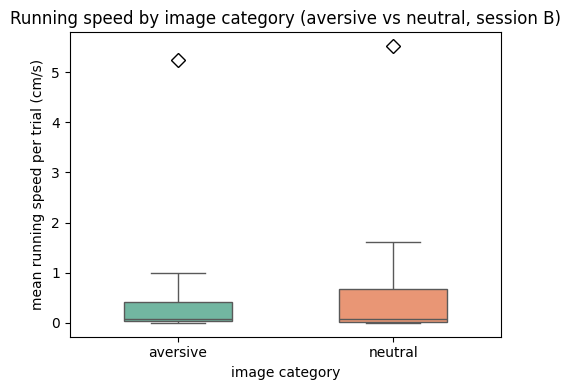

In [22]:
def plot_speed_by_category(trial_df, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    sns.boxplot(data=trial_df, x="category", y="mean_speed", ax=ax,
                showfliers=False, width=0.5, palette="Set2",
                showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white",
                           "markeredgecolor": "black", "markersize": 7})

    ax.set_xlabel("image category")
    ax.set_ylabel("mean running speed per trial (cm/s)")
    ax.set_title("Running speed by image category (aversive vs neutral, session B)")

    return ax

plot_speed_by_category(trial_df)
plt.tight_layout()
plt.show()

In [24]:
def get_neural_activity_per_trial(data, session, stim_name, frame_to_category):
    """
    For each stimulus presentation trial, extract the total (summed) spike activity
    during that trial, and tag it with its frame number and category.

    Returns
    -------
    pd.DataFrame with columns: frame, category, sum_spikes, start, end
    """
    s = data["sessions"][session]
    spikes = s["spikes"]  # shape (n_cells, n_timepoints)
    stim_table = s["stim_tables"][stim_name].copy()

    # Exclude blank sweeps (frame == -1, no image shown)
    stim_table = stim_table[stim_table["frame"] != -1].reset_index(drop=True)

    sum_spikes = []
    for _, row in stim_table.iterrows():
        start, end = int(row["start"]), int(row["end"])
        trial_spikes = spikes[:, start:end + 1]
        sum_spikes.append(np.nansum(trial_spikes))

    stim_table["sum_spikes"] = sum_spikes
    stim_table["category"] = stim_table["frame"].map(frame_to_category)

    return stim_table

           count      mean       std       min       25%       50%       75%  \
category                                                                       
aversive  1850.0  1.282755  1.239957  0.000000  0.386504  0.891998  1.760151   
neutral   4050.0  1.190992  1.206044  0.003033  0.337542  0.788963  1.645466   

               max  
category            
aversive  8.176607  
neutral   9.663793  


/var/folders/42/yzjg5hd11vv65hsck7wh0lb00000gn/T/ipykernel_16339/2444613100.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=neural_df, x="category", y="sum_spikes", ax=ax,


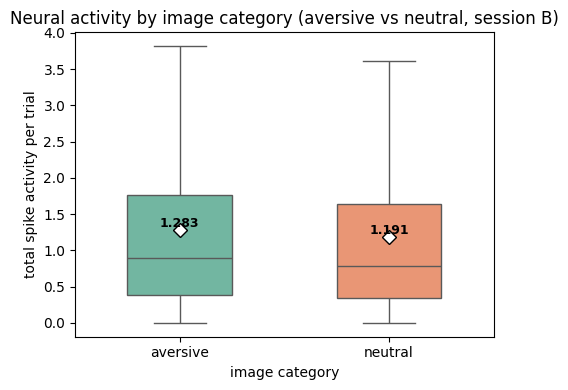

In [25]:
neural_df = get_neural_activity_per_trial(data, session="B", stim_name="natural_scenes",
                                            frame_to_category=frame_to_category)

print(neural_df.groupby("category")["sum_spikes"].describe())

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=neural_df, x="category", y="sum_spikes", ax=ax,
            showfliers=False, width=0.5, palette="Set2",
            showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "white",
                       "markeredgecolor": "black", "markersize": 7})

# Annotate each box with its mean value as text
categories = neural_df["category"].unique()
for i, cat in enumerate(categories):
    mean_val = neural_df[neural_df["category"] == cat]["sum_spikes"].mean()
    ax.text(i, mean_val, f"{mean_val:.3f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="black")

ax.set_xlabel("image category")
ax.set_ylabel("total spike activity per trial")
ax.set_title("Neural activity by image category (aversive vs neutral, session B)")
plt.tight_layout()
plt.show()

# Overall spike activity comparison across different stimulus

### Summary: Overall neurons showed stronger sctivity toward drifting grating. The second one would be natural scenes

In [27]:
STIMULUS_SESSION_MAP = {
    "drifting_gratings":    "A",
    "static_gratings":      "B",
    "natural_scenes":       "B",
    "locally_sparse_noise": "C",
}

def get_neural_activity_by_stimulus(data, stimulus_session_map=STIMULUS_SESSION_MAP):
    """
    Extract total (summed) spike activity during each stimulus's presentation trials,
    across all four stimulus types (spanning sessions A, B, C).

    Returns
    -------
    dict: {stimulus_name: np.ndarray of per-trial summed spike values}
    """
    stimulus_activity = {}

    for stim_name, session in stimulus_session_map.items():
        s = data["sessions"][session]
        spikes = s["spikes"]
        stim_table = s["stim_tables"][stim_name]

        starts = stim_table["start"].astype(int).values
        ends = stim_table["end"].astype(int).values

        trial_sums = [np.nansum(spikes[:, start:end + 1]) for start, end in zip(starts, ends)]
        stimulus_activity[stim_name] = np.array(trial_sums)

    return stimulus_activity

def plot_activity_by_stimulus(stimulus_activity, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    rows = []
    for stim_name, values in stimulus_activity.items():
        for v in values:
            rows.append({"stimulus": stim_name, "sum_spikes": v})
    df_long = pd.DataFrame(rows)

    sns.boxplot(data=df_long, x="stimulus", y="sum_spikes", ax=ax,
                showfliers=False, width=0.5, palette="Set2",
                showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white",
                           "markeredgecolor": "black", "markersize": 7})

    stim_order = list(stimulus_activity.keys())
    for i, stim_name in enumerate(stim_order):
        mean_val = np.mean(stimulus_activity[stim_name])
        ax.text(i, mean_val, f"{mean_val:.3f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color="black")

    ax.set_xlabel("stimulus")
    ax.set_ylabel("total population spike activity per trial")
    ax.set_title("Neural activity across stimulus types")
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

    return ax

/var/folders/42/yzjg5hd11vv65hsck7wh0lb00000gn/T/ipykernel_16339/931326212.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="stimulus", y="sum_spikes", ax=ax,


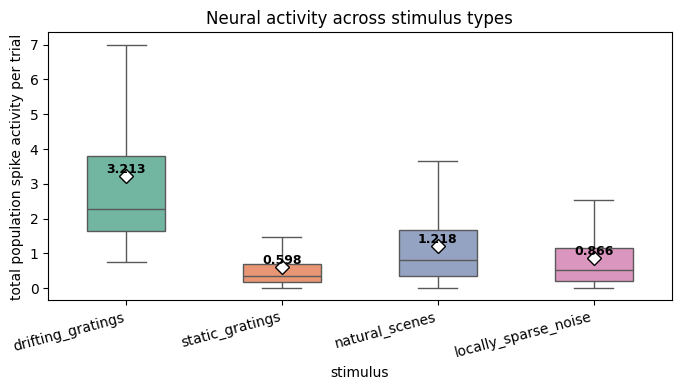

In [28]:
stimulus_activity = get_neural_activity_by_stimulus(data)

fig, ax = plt.subplots(figsize=(7, 4))
plot_activity_by_stimulus(stimulus_activity, ax=ax)
plt.tight_layout()
plt.show()

# raster plots to see how neural respond in each session

### Raster plot with neural activity

In [121]:
def plot_spike_raster(data, session, ax=None, threshold=0.05, xlim=None):
    """
    Plot a raster plot of inferred spike activity across all neurons in a session.
    Each row is a neuron; each vertical tick marks a time point where spike
    activity exceeds the threshold (since OASIS output is continuous, not binary).

    Parameters
    ----------
    threshold : float
        Minimum spike value to count as a "spike event" for raster display.
        Adjust based on your data's typical spike amplitude range.
    xlim : tuple, optional
        (start_time, end_time) in seconds to zoom into a specific window.
    """
    s = data["sessions"][session]
    spikes = s["spikes"]  # shape (n_cells, n_timepoints)
    t = s["t"]
    n_cells = spikes.shape[0]

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6))

    for cell_idx in range(n_cells):
        spike_times = t[spikes[cell_idx] > threshold]
        ax.vlines(spike_times, cell_idx + 0.5, cell_idx + 1.5, color="black", linewidth=0.5)

    ax.set_xlabel("time (s)")
    ax.set_ylabel("neuron #")
    ax.set_ylim(0.5, n_cells + 0.5)
    ax.set_title(f"session {session}: spike raster ({n_cells} neurons)")

    if xlim is not None:
        ax.set_xlim(xlim)

    return ax

In [122]:
for session in ["A", "B", "C"]:
    t = data["sessions"][session]["t"]
    print(f"Session {session}: {t[0]:.1f}s ~ {t[-1]:.1f}s (overall length {t[-1] - t[0]:.1f} sec)")

Session A: 9.7s ~ 3849.6s (overall length 3839.9 sec)
Session B: 25.4s ~ 3811.3s (overall length 3785.9 sec)
Session C: 7.7s ~ 3523.6s (overall length 3515.8 sec)


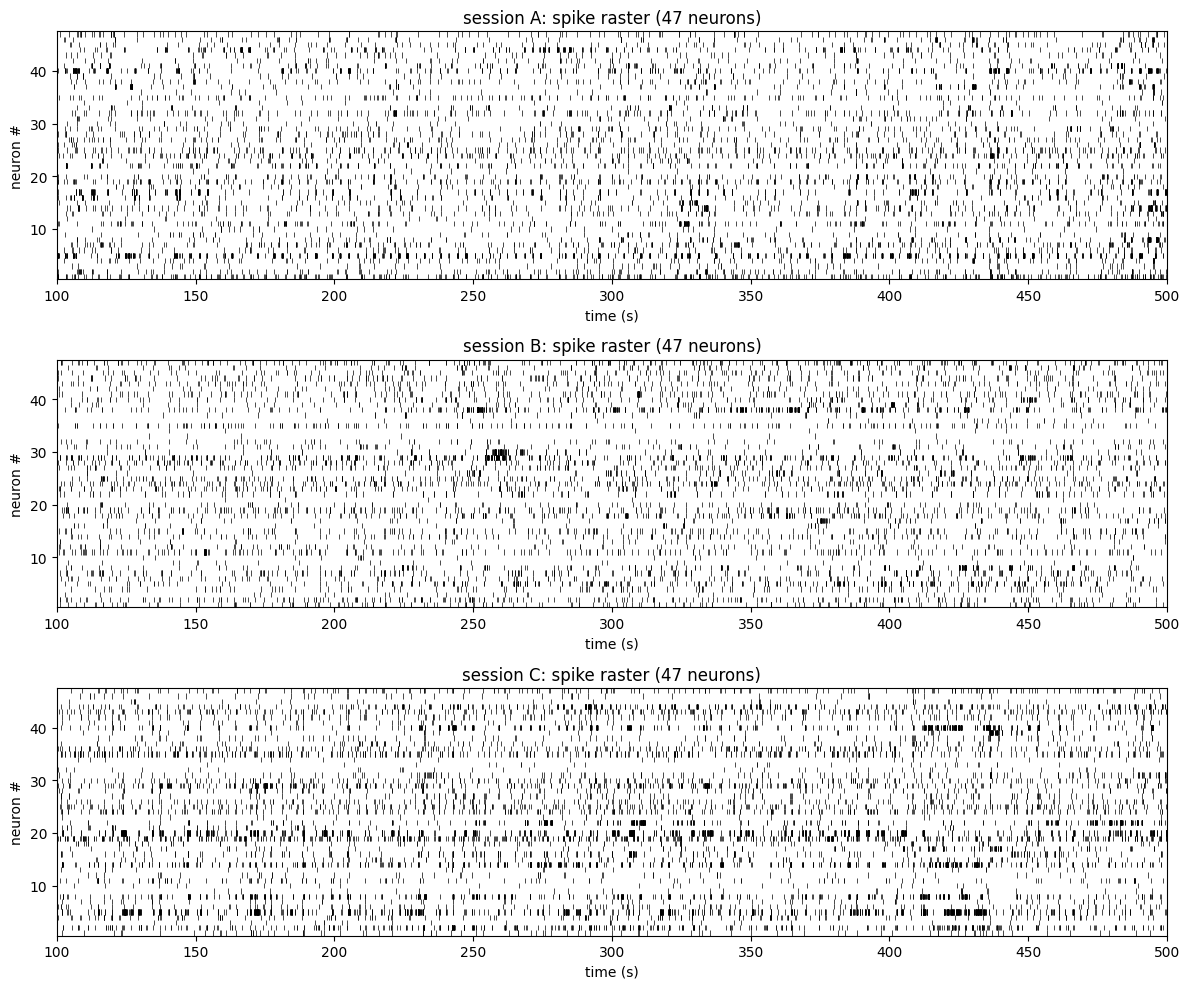

In [123]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

plot_spike_raster(data, session="A", ax=axes[0], threshold=0.02, xlim=(100, 500))
plot_spike_raster(data, session="B", ax=axes[1], threshold=0.02, xlim=(100, 500))
plot_spike_raster(data, session="C", ax=axes[2], threshold=0.02, xlim=(100, 500))

plt.tight_layout()
plt.show()

### Raster plot paired with running speed

In [124]:
def plot_spike_raster_with_running_all_sessions(data, sessions=["A", "B", "C"],
                                                    threshold=0.02, xlim=None,
                                                    use_filtered_speed=True):
    """
    Plot spike raster + running speed for multiple sessions, stacked vertically,
    for easy side-by-side comparison.
    """
    n_sessions = len(sessions)
    fig, axes = plt.subplots(
        n_sessions * 2, 1, figsize=(12, 4 * n_sessions),
        gridspec_kw={"height_ratios": [3, 1] * n_sessions}
    )

    for i, session in enumerate(sessions):
        ax_raster = axes[i * 2]
        ax_speed = axes[i * 2 + 1]

        s = data["sessions"][session]
        spikes = s["spikes"]
        t = s["t"]
        n_cells = spikes.shape[0]

        speed_key = "running_speed_filtered" if use_filtered_speed else "running_speed"
        speed = s[speed_key][0]
        t_speed = s[speed_key][1]

        # Raster
        for cell_idx in range(n_cells):
            spike_times = t[spikes[cell_idx] > threshold]
            ax_raster.vlines(spike_times, cell_idx + 0.5, cell_idx + 1.5,
                              color="black", linewidth=0.5)
        ax_raster.set_ylabel("neuron #")
        ax_raster.set_ylim(0.5, n_cells + 0.5)
        ax_raster.set_title(f"session {session}: spike raster ({n_cells} neurons)")

        # Running speed
        ax_speed.plot(t_speed, speed, lw=0.8, color="darkorange")
        ax_speed.set_ylabel("speed\n(cm/s)")

        if xlim is not None:
            ax_raster.set_xlim(xlim)
            ax_speed.set_xlim(xlim)

    axes[-1].set_xlabel("time (s)")
    plt.tight_layout()
    return fig, axes

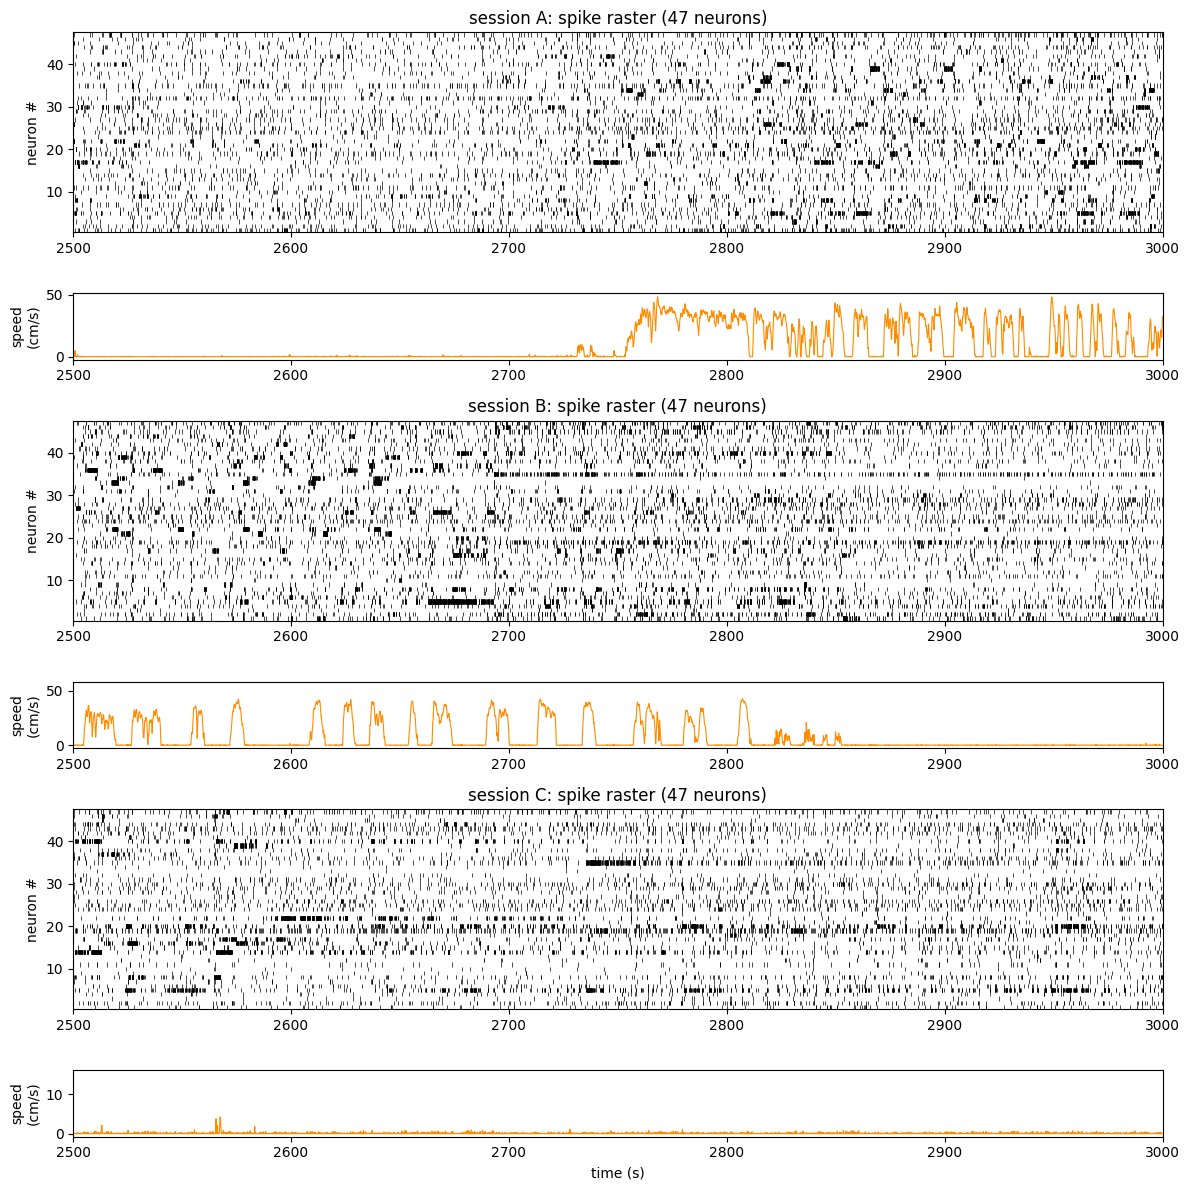

In [125]:
fig, axes = plot_spike_raster_with_running_all_sessions(
    data, sessions=["A", "B", "C"], threshold=0.02, xlim=(2500, 3000)
)
plt.show()

### Raster plot with running and stimulus timing

In [126]:
STIMULUS_SESSION_MAP = {
    "drifting_gratings":    "A",
    "static_gratings":      "B",
    "natural_scenes":       "B",
    "locally_sparse_noise": "C",
}

def add_stimulus_shading(ax, data, session, t, xlim=None):
    """
    Shade the time windows during which any stimulus was being presented,
    using each stimulus's own stim_table (start/end indices into t).
    """
    s = data["sessions"][session]
    session_stims = [name for name, sess in STIMULUS_SESSION_MAP.items() if sess == session]

    for stim_name in session_stims:
        stim_table = s["stim_tables"][stim_name]
        starts = stim_table["start"].astype(int).values
        ends = stim_table["end"].astype(int).values

        for start_idx, end_idx in zip(starts, ends):
            start_t, end_t = t[start_idx], t[end_idx]
            if xlim is not None and (end_t < xlim[0] or start_t > xlim[1]):
                continue
            ax.axvspan(start_t, end_t, color="steelblue", alpha=0.15, zorder=0)


def plot_spike_raster_with_running(data, session, threshold=0.05, xlim=None,
                                      use_filtered_speed=True, figsize=(12, 8)):
    """
    Plot a raster plot of inferred spike activity (top) alongside the
    running speed trace (bottom), with blue shading marking stimulus
    presentation windows.
    """
    s = data["sessions"][session]
    spikes = s["spikes"]
    t = s["t"]
    n_cells = spikes.shape[0]

    speed_key = "running_speed_filtered" if use_filtered_speed else "running_speed"
    speed = s[speed_key][0]
    t_speed = s[speed_key][1]

    fig, (ax_raster, ax_speed) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # Stimulus shading (draw first, so it sits behind the raster/speed lines)
    add_stimulus_shading(ax_raster, data, session, t, xlim=xlim)
    add_stimulus_shading(ax_speed, data, session, t, xlim=xlim)

    # --- Top: spike raster ---
    for cell_idx in range(n_cells):
        spike_times = t[spikes[cell_idx] > threshold]
        ax_raster.vlines(spike_times, cell_idx + 0.5, cell_idx + 1.5,
                          color="black", linewidth=0.5, zorder=2)

    ax_raster.set_ylabel("neuron #")
    ax_raster.set_ylim(0.5, n_cells + 0.5)
    ax_raster.set_title(f"session {session}: spike raster ({n_cells} neurons)")

    # --- Bottom: running speed ---
    ax_speed.plot(t_speed, speed, lw=0.8, color="darkorange", zorder=2)
    ax_speed.set_xlabel("time (s)")
    ax_speed.set_ylabel("running speed\n(cm/s)")

    if xlim is not None:
        ax_raster.set_xlim(xlim)
        ax_speed.set_xlim(xlim)

    plt.tight_layout()
    return fig, (ax_raster, ax_speed)

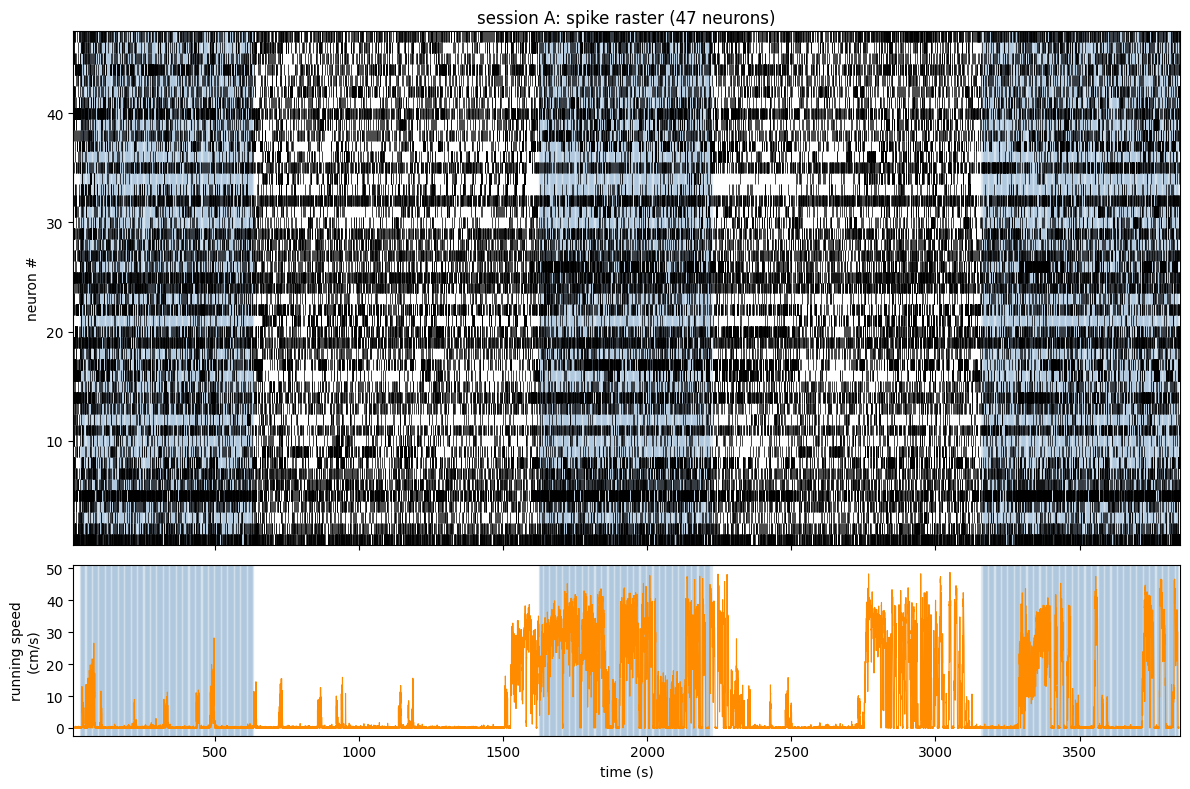

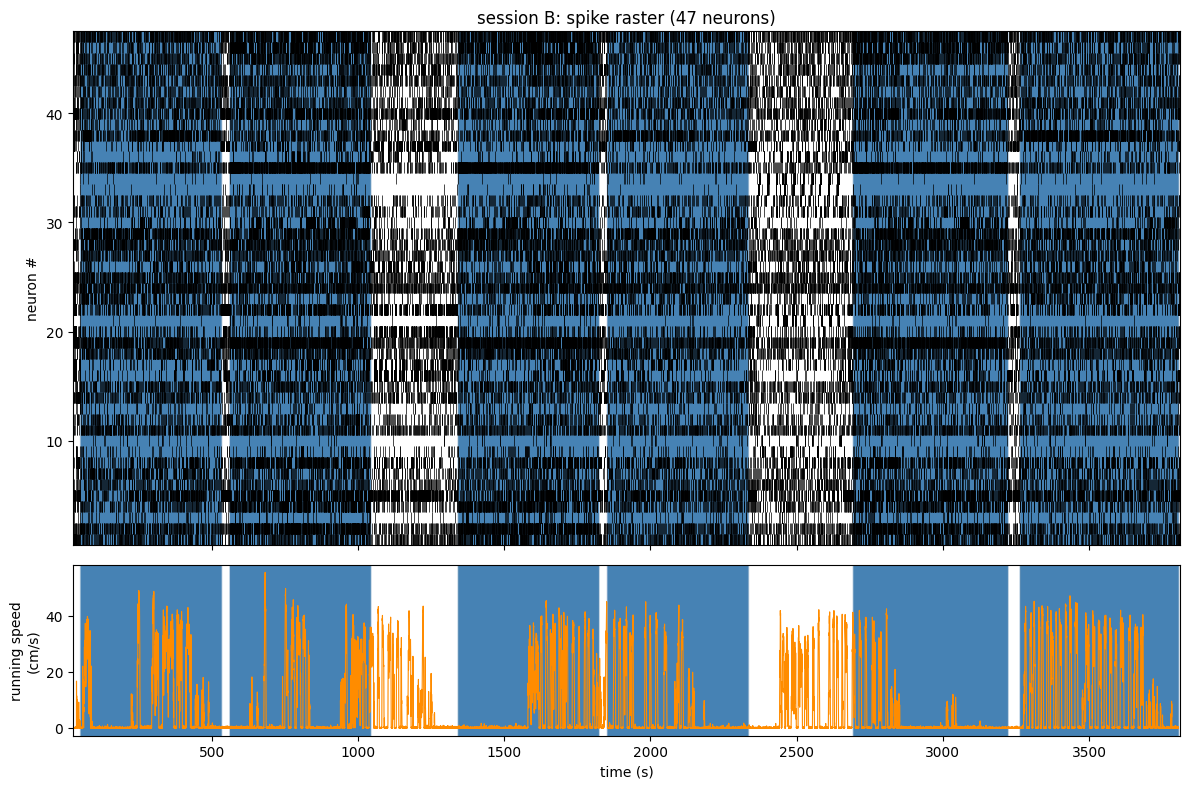

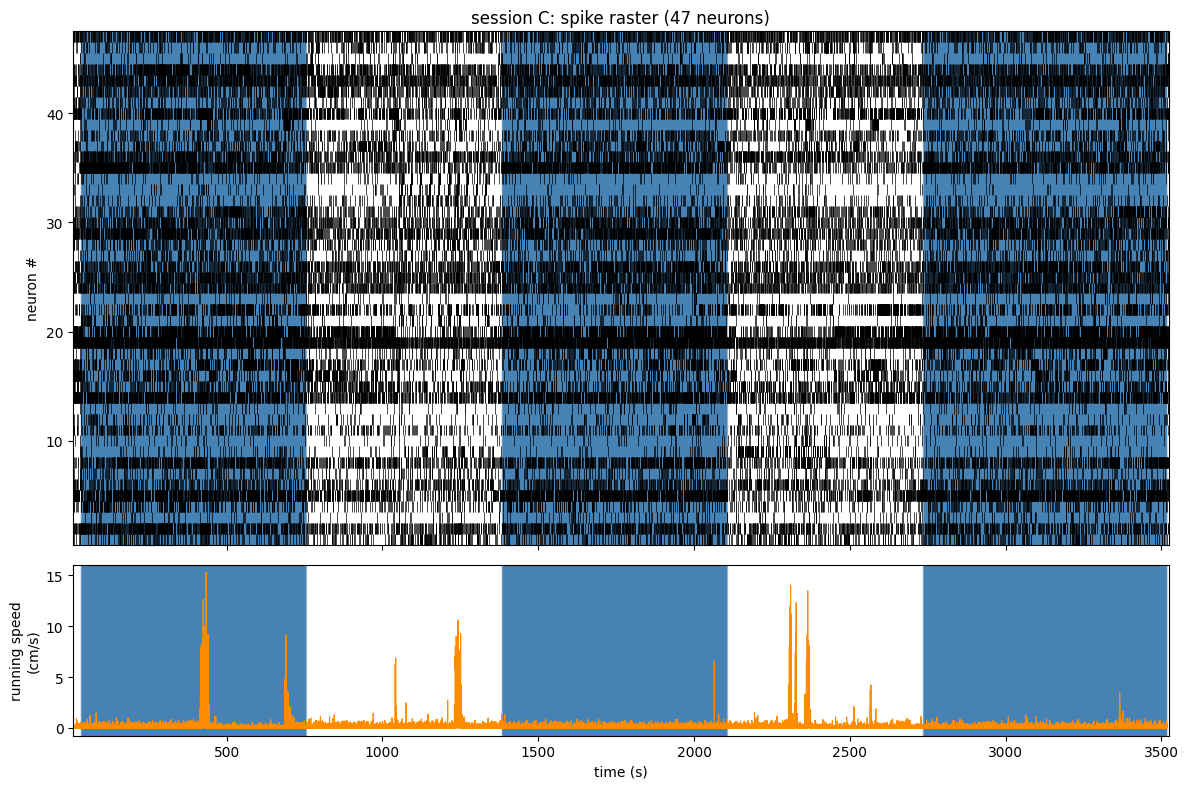

In [127]:
# Session A
fig, (ax_raster, ax_speed) = plot_spike_raster_with_running(
    data, session="A", threshold=0.02, xlim=(9, 3849)
)
plt.show()

# Session B
fig, (ax_raster, ax_speed) = plot_spike_raster_with_running(
    data, session="B", threshold=0.02, xlim=(25, 3811)
)
plt.show()

# Session C
fig, (ax_raster, ax_speed) = plot_spike_raster_with_running(
    data, session="C", threshold=0.02, xlim=(7, 3523)
)
plt.show()

## Using neuron 8, 15, 25, 36 as example neuron

Found this four neurons have different property toward movement

Neuron 8: Only responsive to drifting grating. Show higher activity when moving\
Neuron 15: Only responsive to drifting grating. Show higher activity when not-moving\
Neuron 25: Response to both drifting grating and natural scene. Show higher response when moving\
Neuron 36: Response to both drifting grating and sparse stimuli. 

In [128]:
def plot_spike_raster_subset_with_running(data, session, cell_ids, threshold=0.05, xlim=None,
                                             use_filtered_speed=True, figsize=(12, 6)):
    """
    Plot a raster plot for a SUBSET of neurons, with running speed shown
    below, and blue shading marking stimulus presentation windows.

    Parameters
    ----------
    cell_ids : list of int
        Which neuron indices to plot (e.g. [8, 15, 25, 36]).
    threshold : float
        Minimum spike value to count as a "spike event" for raster display.
    xlim : tuple, optional
        (start_time, end_time) in seconds to zoom into a specific window.
    """
    s = data["sessions"][session]
    spikes = s["spikes"]
    t = s["t"]

    speed_key = "running_speed_filtered" if use_filtered_speed else "running_speed"
    speed = s[speed_key][0]
    t_speed = s[speed_key][1]

    fig, (ax_raster, ax_speed) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    # Stimulus shading (draw first, so it sits behind the raster/speed lines)
    add_stimulus_shading(ax_raster, data, session, t, xlim=xlim)
    add_stimulus_shading(ax_speed, data, session, t, xlim=xlim)

    # --- Top: raster for selected neurons only ---
    for row_idx, cell_idx in enumerate(cell_ids):
        spike_times = t[spikes[cell_idx] > threshold]
        ax_raster.vlines(spike_times, row_idx + 0.5, row_idx + 1.5,
                          color="black", linewidth=0.8, zorder=2)

    ax_raster.set_yticks(np.arange(1, len(cell_ids) + 1))
    ax_raster.set_yticklabels([f"neuron {c}" for c in cell_ids], fontsize=15)
    ax_raster.set_ylim(0.5, len(cell_ids) + 0.5)
    ax_raster.set_title(f"session {session}: spike raster (neurons {cell_ids})", fontsize=15)

    # --- Bottom: running speed ---
    ax_speed.plot(t_speed, speed, lw=0.8, color="darkorange", zorder=2)
    ax_speed.set_xlabel("time (s)", fontsize=15)
    ax_speed.set_ylabel("running speed\n(cm/s)", fontsize=15)
    ax_speed.tick_params(axis="both", labelsize=15)  


    if xlim is not None:
        ax_raster.set_xlim(xlim)
        ax_speed.set_xlim(xlim)

    plt.tight_layout()
    return fig, (ax_raster, ax_speed)

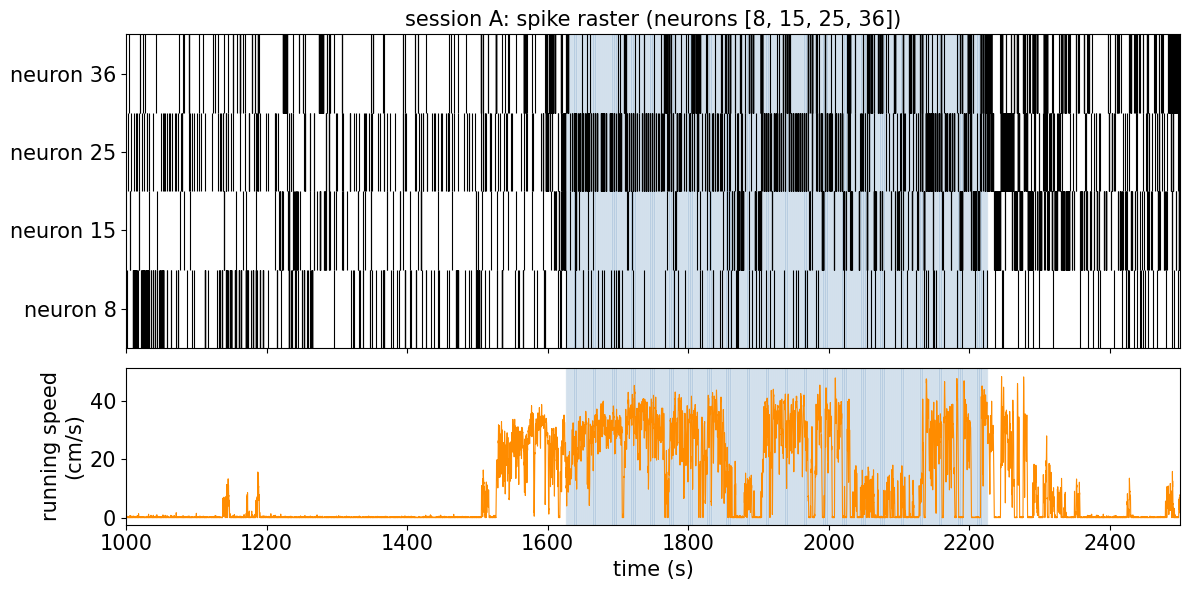

In [129]:
# Session A
fig, (ax_raster, ax_speed) = plot_spike_raster_subset_with_running(
    data, session="A", cell_ids=[8, 15, 25, 36], threshold=0.02, xlim=(1000, 2500)
)
plt.show()

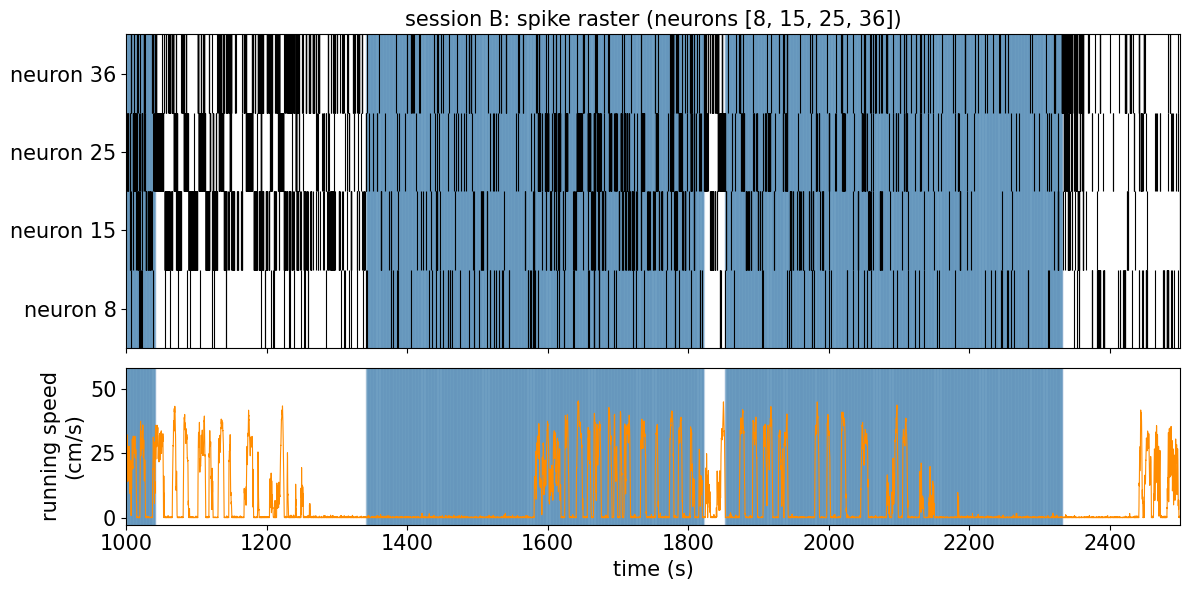

In [130]:
# Session B
fig, (ax_raster, ax_speed) = plot_spike_raster_subset_with_running(
    data, session="B", cell_ids=[8, 15, 25, 36], threshold=0.02, xlim=(1000, 2500)
)
plt.show()

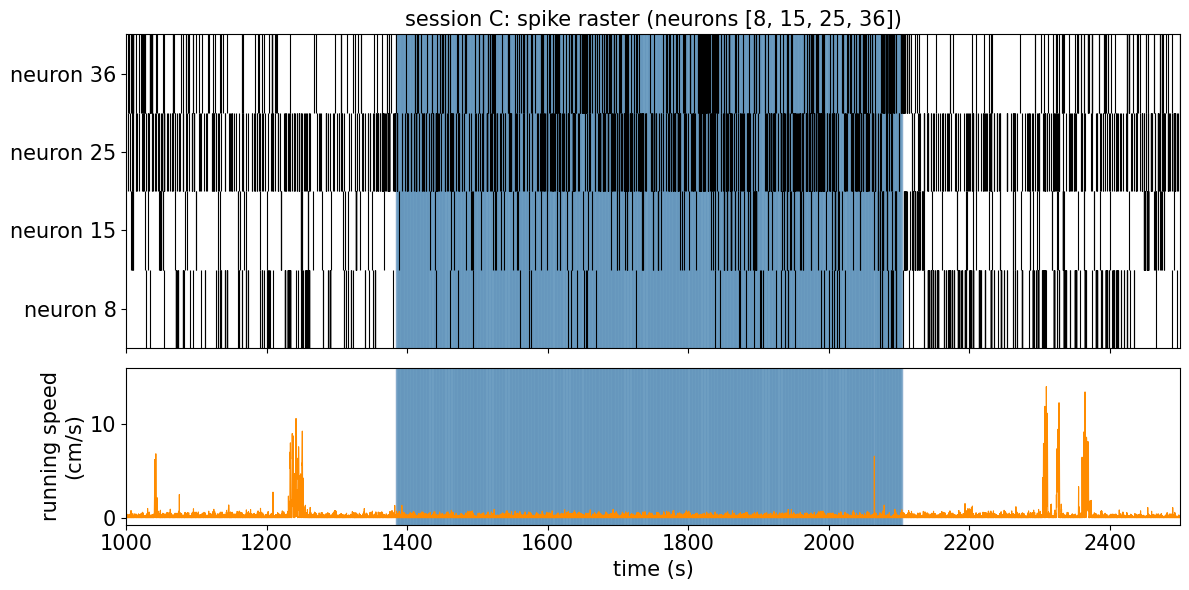

In [131]:
# Session C
fig, (ax_raster, ax_speed) = plot_spike_raster_subset_with_running(
    data, session="C", cell_ids=[8, 15, 25, 36], threshold=0.02, xlim=(1000, 2500)
)
plt.show()

# Compare the neural activity within stimulus onset between moving and non-moving

In [45]:
def compare_neuron_activity_by_movement(data, session, stim_name, cell_ids,
                                          phase_key="running_speed_phase"):
    """
    For specific neurons, compare spike activity during stimulus presentation
    trials, split by whether the mouse was moving or stationary during
    each trial (majority vote based on running_speed_phase).

    Parameters
    ----------
    cell_ids : list of int
        Which neuron indices to analyze (e.g. [25, 36]).

    Returns
    -------
    pd.DataFrame with columns: cell, movement_state, sum_spikes, start, end
    """
    s = data["sessions"][session]
    spikes = s["spikes"]
    phase = s[phase_key]  # 0 = still, 1 = moving, -1 = invalid
    stim_table = s["stim_tables"][stim_name].copy()

    if "frame" in stim_table.columns:
        stim_table = stim_table[stim_table["frame"] != -1].reset_index(drop=True)

    rows = []
    for _, row in stim_table.iterrows():
        start, end = int(row["start"]), int(row["end"])
        trial_phase = phase[start:end + 1]
        trial_phase = trial_phase[trial_phase != -1]
        if len(trial_phase) == 0:
            continue

        # Majority vote: is the mouse moving for most of this trial?
        state = "moving" if np.mean(trial_phase) > 0.5 else "stationary"

        for cell_id in cell_ids:
            trial_spikes = spikes[cell_id, start:end + 1]
            rows.append({
                "cell": cell_id,
                "movement_state": state,
                "sum_spikes": np.nansum(trial_spikes),
                "start": start,
                "end": end,
            })

    return pd.DataFrame(rows)

In [46]:
cell_ids = [25, 36]

df = compare_neuron_activity_by_movement(
    data, session="A", stim_name="drifting_gratings", cell_ids=cell_ids
)

print(df.groupby(["cell", "movement_state"])["sum_spikes"].describe())

                     count      mean       std  min       25%       50%  \
cell movement_state                                                       
25   moving          266.0  0.101317  0.397166  0.0  0.000000  0.000000   
     stationary      362.0  0.022952  0.037750  0.0  0.004248  0.016536   
36   moving          266.0  0.143445  0.607981  0.0  0.000000  0.003892   
     stationary      362.0  0.116750  0.753920  0.0  0.000000  0.004017   

                          75%        max  
cell movement_state                       
25   moving          0.035006   3.162265  
     stationary      0.031492   0.532258  
36   moving          0.021831   7.412800  
     stationary      0.019744  11.401155  


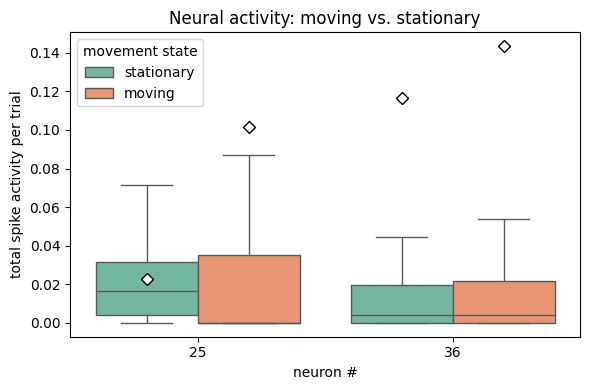

In [47]:
def plot_neuron_activity_by_movement(df, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))

    sns.boxplot(data=df, x="cell", y="sum_spikes", hue="movement_state", ax=ax,
                showfliers=False, palette="Set2",
                showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white",
                           "markeredgecolor": "black", "markersize": 6})

    ax.set_xlabel("neuron #")
    ax.set_ylabel("total spike activity per trial")
    ax.set_title("Neural activity: moving vs. stationary")
    ax.legend(title="movement state")

    return ax

fig, ax = plt.subplots(figsize=(6, 4))
plot_neuron_activity_by_movement(df, ax=ax)
plt.tight_layout()
plt.show()

In [60]:
def compare_activity_by_movement_all_stimuli(data, stimulus_session_map=STIMULUS_SESSION_MAP,
                                                 cell_ids=None, phase_key="running_speed_phase"):
    """
    For each stimulus type, compare spike activity between moving and
    stationary trials, separately for each specified neuron.

    Parameters
    ----------
    cell_ids : list of int, optional
        If specified, compute activity separately for each of these neurons.
        If None, use all cells combined (population-level sum, labeled as "all_cells").

    Returns
    -------
    pd.DataFrame with columns: stimulus, cell, movement_state, sum_spikes
    """
    rows = []

    for stim_name, session in stimulus_session_map.items():
        s = data["sessions"][session]
        spikes = s["spikes"]
        phase = s[phase_key]
        stim_table = s["stim_tables"][stim_name].copy()

        if "frame" in stim_table.columns:
            stim_table = stim_table[stim_table["frame"] != -1].reset_index(drop=True)

        cells_to_use = cell_ids if cell_ids is not None else [None]  # None = all cells combined

        for _, row in stim_table.iterrows():
            start, end = int(row["start"]), int(row["end"])
            trial_phase = phase[start:end + 1]
            trial_phase = trial_phase[trial_phase != -1]
            if len(trial_phase) == 0:
                continue

            state = "moving" if np.mean(trial_phase) > 0.5 else "stationary"

            for cell_id in cells_to_use:
                if cell_id is None:
                    trial_activity = np.nansum(spikes[:, start:end + 1])
                    cell_label = "all_cells"
                else:
                    trial_activity = np.nansum(spikes[cell_id, start:end + 1])
                    cell_label = f"neuron{cell_id}"

                rows.append({
                    "stimulus": stim_name,
                    "neuron": cell_label,
                    "movement_state": state,
                    "sum_spikes": trial_activity,
                })

    return pd.DataFrame(rows)

In [61]:
df_movement = compare_activity_by_movement_all_stimuli(data, cell_ids=[8, 15, 25, 36])

print(df_movement.groupby(["neuron", "stimulus", "movement_state"])["sum_spikes"].describe())

                                               count      mean       std  min  \
neuron   stimulus             movement_state                                    
neuron15 drifting_gratings    moving           266.0  0.035499  0.164767  0.0   
                              stationary       362.0  0.183101  0.729195  0.0   
         locally_sparse_noise moving            61.0  0.004926  0.016745  0.0   
                              stationary      8819.0  0.009612  0.060211  0.0   
         natural_scenes       moving          1370.0  0.004759  0.019019  0.0   
                              stationary      4530.0  0.016150  0.094979  0.0   
         static_gratings      moving          1985.0  0.001423  0.004311  0.0   
                              stationary      4015.0  0.011997  0.065473  0.0   
neuron25 drifting_gratings    moving           266.0  0.101317  0.397166  0.0   
                              stationary       362.0  0.022952  0.037750  0.0   
         locally_sparse_nois

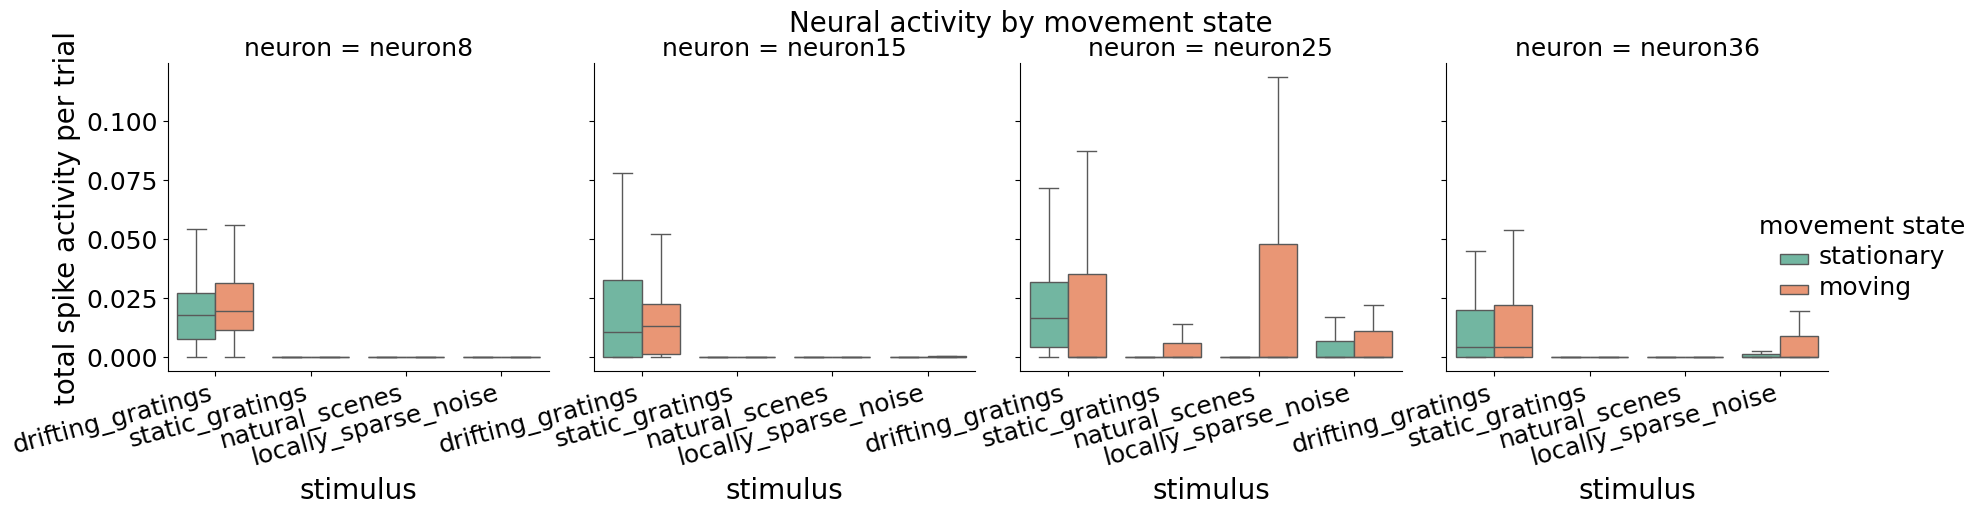

In [76]:
def plot_activity_by_movement_per_cell(df):
    g = sns.catplot(
        data=df, x="stimulus", y="sum_spikes", hue="movement_state",
        col="neuron", kind="box", showfliers=False, palette="Set2",
        height=4, aspect=1.1
    )
    g.set_xticklabels(rotation=15, ha="right",fontsize=18)
    g.set_axis_labels("stimulus", "total spike activity per trial", fontsize=20)
    g.fig.suptitle("Neural activity by movement state", y=1.05, fontsize=20)

    # Set title and tick label sizes for each subplot
    for ax in g.axes.flat:
        ax.set_title(ax.get_title(), fontsize=18)
        ax.tick_params(axis="y", labelsize=18)

    # Increase legend font size
    if g.legend is not None:
        g.legend.set_title("movement state", prop={"size": 18})
        for text in g.legend.get_texts():
            text.set_fontsize(18)
    return g

plot_activity_by_movement_per_cell(df_movement)
plt.show()

### Here I scan all the neurons trying to see who show interesting property

In [51]:
def plot_all_neurons_movement_grid(data, stimulus_session_map=STIMULUS_SESSION_MAP,
                                       phase_key="running_speed_phase", cols=6):
    df_all = compare_activity_by_movement_all_stimuli(data, cell_ids=list(range(47)))

    n_cells = 47
    rows = int(np.ceil(n_cells / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.2), sharey=False)

    for i, ax in enumerate(axes.flat):
        if i >= n_cells:
            ax.axis("off")
            continue
        cell_df = df_all[df_all["cell"] == f"cell_{i}"]
        sns.boxplot(data=cell_df, x="stimulus", y="sum_spikes", hue="movement_state",
                    ax=ax, showfliers=False, palette="Set2", legend=False)
        ax.set_title(f"cell {i}", fontsize=8)
        ax.set_xlabel("")
        ax.set_ylabel("")
        plt.setp(ax.get_xticklabels(), rotation=90, fontsize=6)

    plt.tight_layout()
    return fig, axes

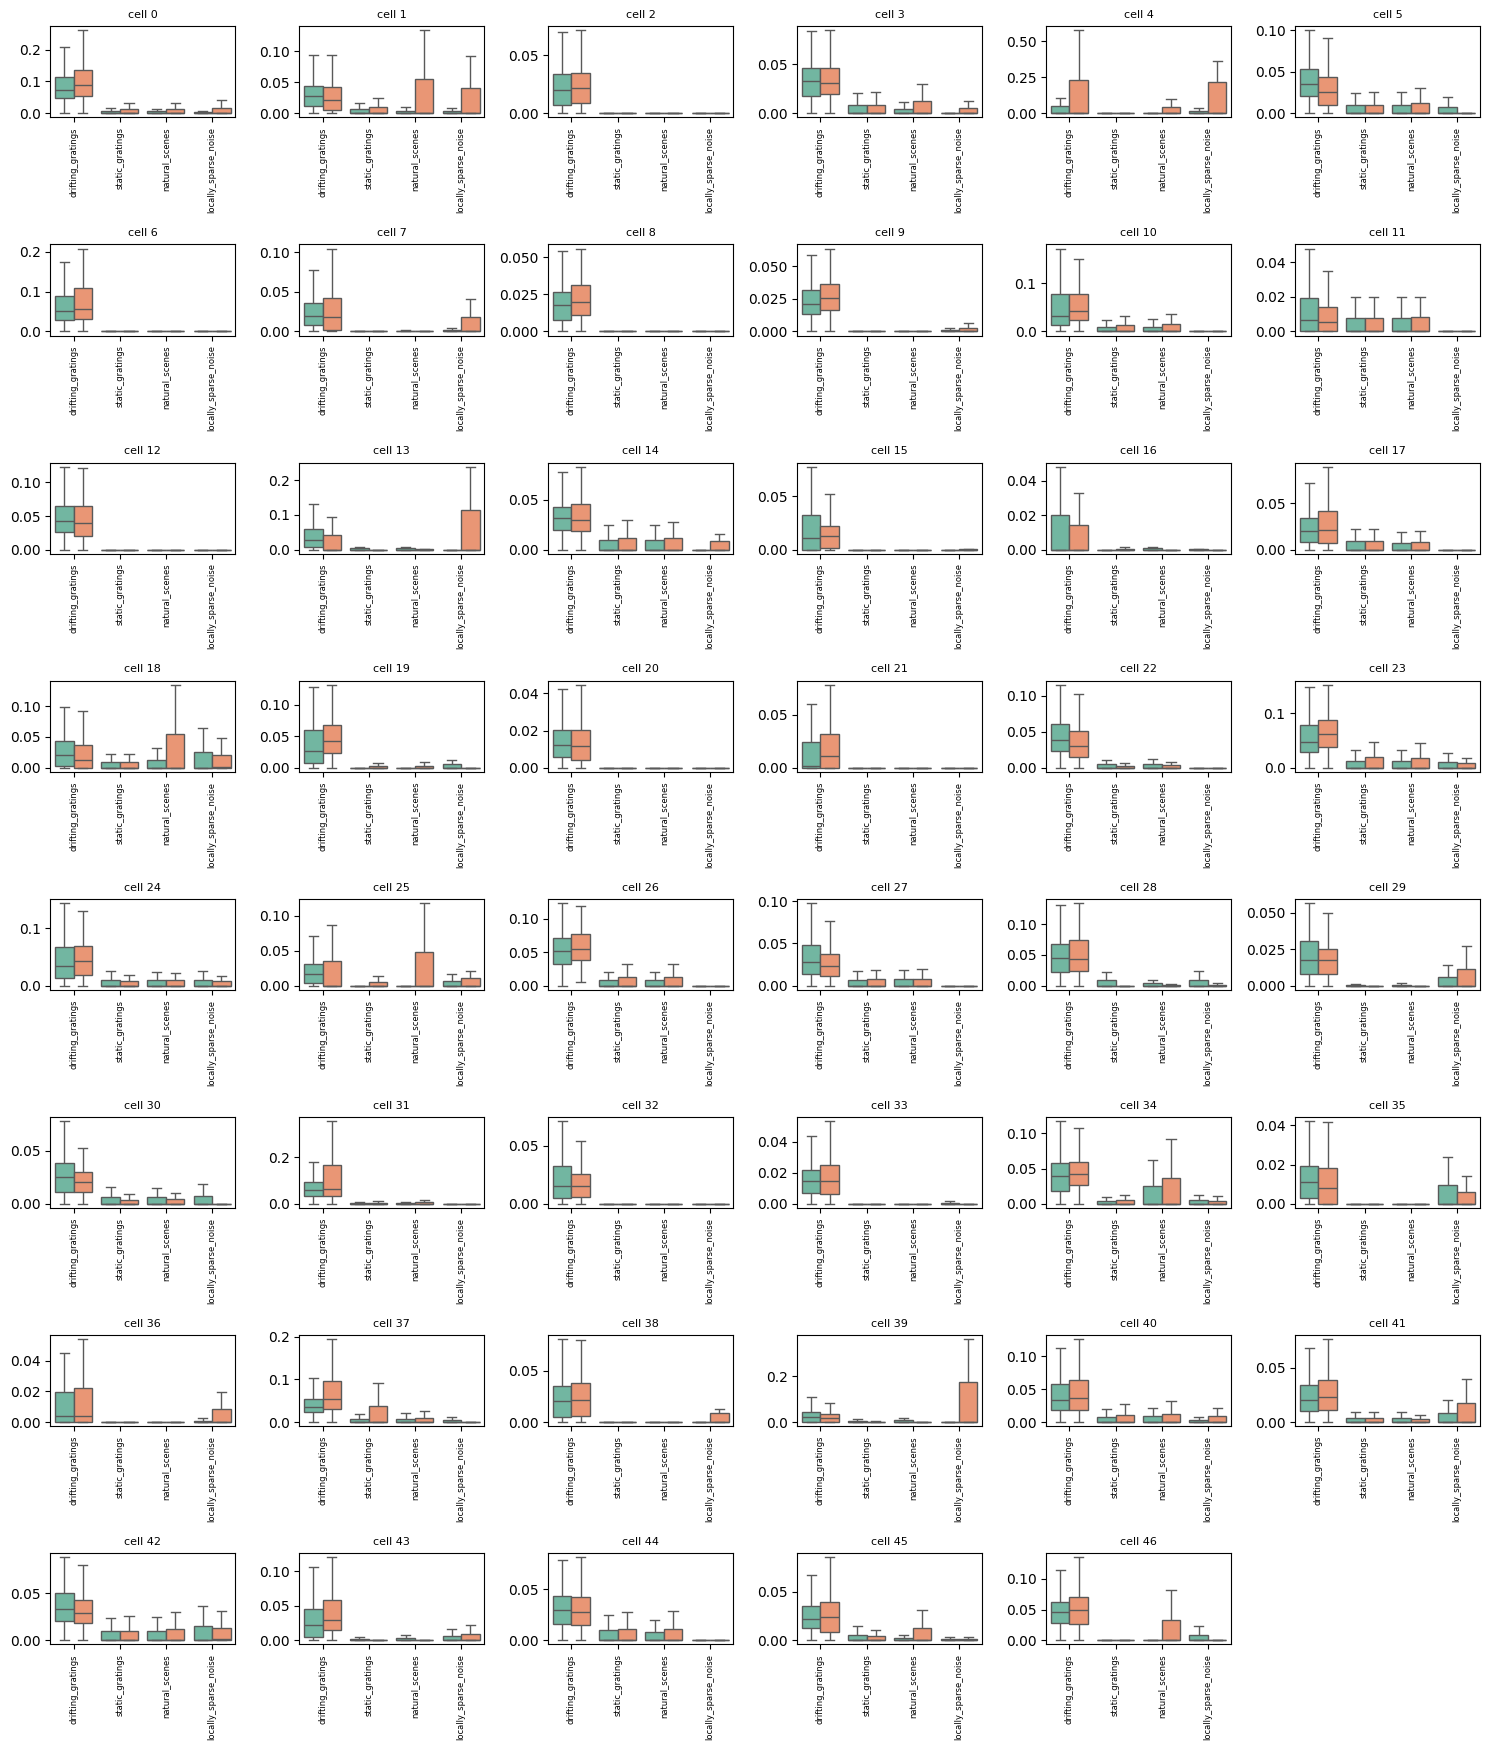

In [52]:
fig, axes = plot_all_neurons_movement_grid(data)
plt.show()